In [129]:
import os
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from pydantic import BaseModel, Field 
from typing import TypedDict, Annotated
import operator


In [130]:
# import os
# from langgraph.graph import StateGraph, START, END
# from langchain_openai import ChatOpenAI
# from dotenv import load_dotenv
# from pydantic import BaseModel, Field 
# from typing import TypedDict, Annotated
# import operator

# load_dotenv()
# model= ChatOpenAI(model='gpt-4o-mini')

# class EvaluationSchema(BaseModel):
#     feedback: str= Field(description="Detailed Feedback of the assay")
#     score: float= Field(description= "score out of 10", ge=0.1, le= 10)

# structured_model= model.with_structured_output(EvaluationSchema)

# essay="""India in the Age of AI
# As the world enters a transformative era defined by artificial intelligence (AI), India stands at a critical juncture — one where it can either emerge as a global leader in AI innovation or risk falling behind in the technology race. The age of AI brings with it immense promise as well as unprecedented challenges, and how India navigates this landscape will shape its socio-economic and geopolitical future.
# India's strengths in the AI domain are rooted in its vast pool of skilled engineers, a thriving IT industry, and a growing startup ecosystem. With over 5 million STEM graduates annually and a burgeoning base of AI researchers, India possesses the intellectual capital required to build cutting-edge AI systems. Institutions like IITs, IIITs, and IISc have begun fostering AI research, while private players such as TCS, Infosys, and Wipro are integrating AI into their global services. In 2020, the government launched the National AI Strategy (AI for All) with a focus on inclusive growth, aiming to leverage AI in healthcare, agriculture, education, and smart mobility.
# One of the most promising applications of AI in India lies in agriculture, where predictive analytics can guide farmers on optimal sowing times, weather forecasts, and pest control. In healthcare, AI-powered diagnostics can help address India’s doctor-patient ratio crisis, particularly in rural areas. Educational platforms are increasingly using AI to personalize learning paths, while smart governance tools are helping improve public service delivery and fraud detection.
# However, the path to AI-led growth is riddled with challenges. Chief among them is the digital divide. While metropolitan cities may embrace AI-driven solutions, rural India continues to struggle with basic internet access and digital literacy. The risk of job displacement due to automation also looms large, especially for low-skilled workers. Without effective skilling and re-skilling programs, AI could exacerbate existing socio-economic inequalities.
# Another pressing concern is data privacy and ethics. As AI systems rely heavily on vast datasets, ensuring that personal data is used transparently and responsibly becomes vital. India is still shaping its data protection laws, and in the absence of a strong regulatory framework, AI systems may risk misuse or bias.
# To harness AI responsibly, India must adopt a multi-stakeholder approach involving the government, academia, industry, and civil society. Policies should promote open datasets, encourage responsible innovation, and ensure ethical AI practices. There is also a need for international collaboration, particularly with countries leading in AI research, to gain strategic advantage and ensure interoperability in global systems.
# India’s demographic dividend, when paired with responsible AI adoption, can unlock massive economic growth, improve governance, and uplift marginalized communities. But this vision will only materialize if AI is seen not merely as a tool for automation, but as an enabler of human-centered development.
# In conclusion, India in the age of AI is a story in the making — one of opportunity, responsibility, and transformation. The decisions we make today will not just determine India’s AI trajectory, but also its future as an inclusive, equitable, and innovation-driven society."""

# prompt= f" Evaluate the langauge quality of the following essay amd provide a feedback ans assign a score out of 10 \n {essay}"
# result= structured_model.invoke(prompt)

# class UPSCState(TypedDict):

#     essay: str
#     language_feedback: str
#     analysis_feedback: str
#     clarity_feedback: str
#     overall_feedback: str
#     individual_scores: Annotated[list[float], operator.add]
#     # individual_scores: list
#     avg_score: float

# def evaluation_language(state: UPSCState):
#     prompt= f" Evaluate the language quality of the following essay and provide a feedback and also mention the evaluation score out of 10 \n {state['essay']}"
#     output= structured_model.invoke(prompt)
#     print(f" language output.feedback: {output.feedback},  output.score: { output.score} ")
#     return {'language_feedback':output.feedback, 'individual_scores': output.score}

# def evaluate_analysis(state: UPSCState):
#     prompt= f" Evaluate the depth of the analysis and provide the feedback and assign a score out of 10 \n {state['essay']}"
#     output= structured_model.invoke(prompt)
#     print(f" analysis output.feedback: {output.feedback},  output.score: { output.score} ")
#     return {'analysis_feedback': output.feedback, 'individual_scores': output.score}

# def evaluate_thought(state: UPSCState):
#     prompt= f" Evaluate the clarity of the thought in the following essay and provide the feedback and also assign a score out of 10 \n {state['essay']}"
#     output= structured_model.invoke(prompt)
#     print(f"thought output.feedback: {output.feedback},  output.score: { output.score} ")
#     return {'clarity_feedback': output.feedback, 'individual_scores': output.score}



# def final_evaluation(state: UPSCState):

#     # summary feedback
#     prompt = f'Based on the following feedbacks create a summarized feedback \n language feedback - {state["language_feedback"]} \n depth of analysis feedback - {state["analysis_feedback"]} \n clarity of thought feedback - {state["clarity_feedback"]}'
#     overall_feedback = model.invoke(prompt).content
#     print(f" state: {state}")
#     print(f" state['individual_scores']: {state['individual_scores']}")
#     print(f"final output.feedback: {overall_feedback}")
#     # avg calculate
#     avg_score = sum(state['individual_scores'])/len(state['individual_scores'])
#     return {'overall_feedback': overall_feedback, 'avg_score': avg_score}

# graph= StateGraph(UPSCState)

# # add nodes
# graph.add_node('evaluation_language', evaluation_language)
# graph.add_node('evaluate_analysis', evaluate_analysis)
# graph.add_node('evaluate_thought',evaluate_thought)
# graph.add_node('final_evaluation', final_evaluation)

# # add edges
# graph.add_edge(START, 'evaluation_language')
# graph.add_edge(START, 'evaluate_analysis')
# graph.add_edge(START, 'evaluate_thought')

# graph.add_edge('evaluation_language', 'final_evaluation')
# graph.add_edge('evaluate_analysis', 'final_evaluation')
# graph.add_edge('evaluate_thought', 'final_evaluation')

# graph.add_edge('final_evaluation', END)

# workflow= graph.compile()

# essay_2= """India and AI Time

# Now world change very fast because new tech call Artificial Intel… something (AI). India also want become big in this AI thing. If work hard, India can go top. But if no careful, India go back.

# India have many good. We have smart student, many engine-ear, and good IT peoples. Big company like TCS, Infosys, Wipro already use AI. Government also do program “AI for All”. It want AI in farm, doctor place, school and transport.

# In farm, AI help farmer know when to put seed, when rain come, how stop bug. In health, AI help doctor see sick early. In school, AI help student learn good. Government office use AI to find bad people and work fast.

# But problem come also. First is many villager no have phone or internet. So AI not help them. Second, many people lose job because AI and machine do work. Poor people get more bad.

# One more big problem is privacy. AI need big big data. Who take care? India still make data rule. If no strong rule, AI do bad.

# India must all people together  Then India grow big and world say "good job India"."""


# initial_state= {
#     'essay' : essay_2
# }
# workflow.invoke(initial_state)





In [131]:
load_dotenv()
model= ChatOpenAI(model='gpt-4o-mini')

In [132]:
class EvaluationSchema(BaseModel):
    feedback: str= Field(description="Detailed Feedback of the assay")
    score: float= Field(description= "score out of 10", ge=0.1, le= 10)
    

In [133]:
structured_model= model.with_structured_output(EvaluationSchema)

In [134]:
essay="""India in the Age of AI
As the world enters a transformative era defined by artificial intelligence (AI), India stands at a critical juncture — one where it can either emerge as a global leader in AI innovation or risk falling behind in the technology race. The age of AI brings with it immense promise as well as unprecedented challenges, and how India navigates this landscape will shape its socio-economic and geopolitical future.
India's strengths in the AI domain are rooted in its vast pool of skilled engineers, a thriving IT industry, and a growing startup ecosystem. With over 5 million STEM graduates annually and a burgeoning base of AI researchers, India possesses the intellectual capital required to build cutting-edge AI systems. Institutions like IITs, IIITs, and IISc have begun fostering AI research, while private players such as TCS, Infosys, and Wipro are integrating AI into their global services. In 2020, the government launched the National AI Strategy (AI for All) with a focus on inclusive growth, aiming to leverage AI in healthcare, agriculture, education, and smart mobility.
One of the most promising applications of AI in India lies in agriculture, where predictive analytics can guide farmers on optimal sowing times, weather forecasts, and pest control. In healthcare, AI-powered diagnostics can help address India’s doctor-patient ratio crisis, particularly in rural areas. Educational platforms are increasingly using AI to personalize learning paths, while smart governance tools are helping improve public service delivery and fraud detection.
However, the path to AI-led growth is riddled with challenges. Chief among them is the digital divide. While metropolitan cities may embrace AI-driven solutions, rural India continues to struggle with basic internet access and digital literacy. The risk of job displacement due to automation also looms large, especially for low-skilled workers. Without effective skilling and re-skilling programs, AI could exacerbate existing socio-economic inequalities.
Another pressing concern is data privacy and ethics. As AI systems rely heavily on vast datasets, ensuring that personal data is used transparently and responsibly becomes vital. India is still shaping its data protection laws, and in the absence of a strong regulatory framework, AI systems may risk misuse or bias.
To harness AI responsibly, India must adopt a multi-stakeholder approach involving the government, academia, industry, and civil society. Policies should promote open datasets, encourage responsible innovation, and ensure ethical AI practices. There is also a need for international collaboration, particularly with countries leading in AI research, to gain strategic advantage and ensure interoperability in global systems.
India’s demographic dividend, when paired with responsible AI adoption, can unlock massive economic growth, improve governance, and uplift marginalized communities. But this vision will only materialize if AI is seen not merely as a tool for automation, but as an enabler of human-centered development.
In conclusion, India in the age of AI is a story in the making — one of opportunity, responsibility, and transformation. The decisions we make today will not just determine India’s AI trajectory, but also its future as an inclusive, equitable, and innovation-driven society."""


In [135]:
prompt= f" Evaluate the langauge quality of the following essay amd provide a feedback ans assign a score out of 10 \n {essay}"
result= structured_model.invoke(prompt)

In [136]:
print(f" result as feedback: {result.feedback}")
print(f" score is as: {result.score}")

 result as feedback: The essay presents a well-structured analysis of India's current position and potential in the field of artificial intelligence. The language is formal and academic, appropriate for the topic, demonstrating a good command of vocabulary and syntax. The arguments are coherent and logically sequenced, providing a balanced view by addressing both opportunities and challenges associated with AI in India. However, a few areas could be improved for clarity and depth: 

1. **Introduction & Thesis Statement**: The introduction successfully sets the stage but could benefit from a clearer thesis statement that defines the main argument of the essay more explicitly. 

2. **Supporting Evidence**: While various applications of AI are mentioned, the essay could strengthen its arguments with specific examples or case studies illustrating successful AI implementations in India. For instance, mentioning specific AI startups or government initiatives that have shown measurable succes

In [137]:
class UPSCState(TypedDict):

    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[float], operator.add]
    # individual_scores: list
    avg_score: float


In [138]:
def evaluation_language(state: UPSCState):
    prompt= f" Evaluate the language quality of the following essay and provide a feedback and also mention the evaluation score out of 10 \n {state['essay']}"
    output= structured_model.invoke(prompt)
    print(f" language output.feedback: {output.feedback},  output.score: { output.score} ")
    return {'language_feedback':output.feedback, 'individual_scores': [output.score]}

In [139]:
def evaluate_analysis(state: UPSCState):
    prompt= f" Evaluate the depth of the analysis and provide the feedback and assign a score out of 10 \n {state['essay']}"
    output= structured_model.invoke(prompt)
    print(f" analysis output.feedback: {output.feedback},  output.score: { output.score} ")
    return {'analysis_feedback': output.feedback, 'individual_scores': [output.score]}


In [140]:
def evaluate_thought(state: UPSCState):
    prompt= f" Evaluate the clarity of the thought in the following essay and provide the feedback and also assign a score out of 10 \n {state['essay']}"
    output= structured_model.invoke(prompt)
    print(f"thought output.feedback: {output.feedback},  output.score: { output.score} ")
    return {'clarity_feedback': output.feedback, 'individual_scores': [output.score]}

In [141]:


def final_evaluation(state: UPSCState):

    # summary feedback
    prompt = f'Based on the following feedbacks create a summarized feedback \n language feedback - {state["language_feedback"]} \n depth of analysis feedback - {state["analysis_feedback"]} \n clarity of thought feedback - {state["clarity_feedback"]}'
    overall_feedback = model.invoke(prompt).content
    print(f" state: {state}")
    print(f" state['individual_scores']: {state['individual_scores']}")
    print(f"final output.feedback: {overall_feedback}")
    # avg calculate
    avg_score = sum(state['individual_scores'])/len(state['individual_scores'])
    return {'overall_feedback': overall_feedback, 'avg_score': avg_score}

In [142]:
graph= StateGraph(UPSCState)

# add nodes
graph.add_node('evaluation_language', evaluation_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_thought',evaluate_thought)
graph.add_node('final_evaluation', final_evaluation)

# add edges
graph.add_edge(START, 'evaluation_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_thought')

graph.add_edge('evaluation_language', 'final_evaluation')
graph.add_edge('evaluate_analysis', 'final_evaluation')
graph.add_edge('evaluate_thought', 'final_evaluation')

graph.add_edge('final_evaluation', END)

workflow= graph.compile()



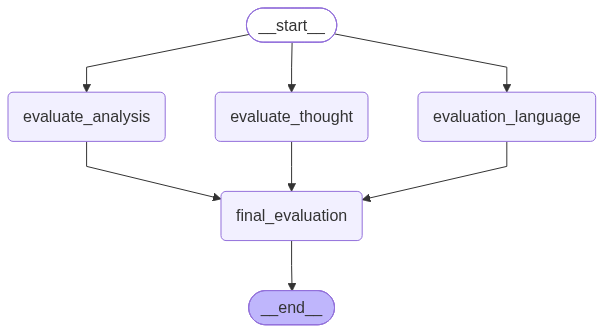

In [143]:
workflow

In [144]:
essay_2= """India and AI Time

Now world change very fast because new tech call Artificial Intel… something (AI). India also want become big in this AI thing. If work hard, India can go top. But if no careful, India go back.

India have many good. We have smart student, many engine-ear, and good IT peoples. Big company like TCS, Infosys, Wipro already use AI. Government also do program “AI for All”. It want AI in farm, doctor place, school and transport.

In farm, AI help farmer know when to put seed, when rain come, how stop bug. In health, AI help doctor see sick early. In school, AI help student learn good. Government office use AI to find bad people and work fast.

But problem come also. First is many villager no have phone or internet. So AI not help them. Second, many people lose job because AI and machine do work. Poor people get more bad.

One more big problem is privacy. AI need big big data. Who take care? India still make data rule. If no strong rule, AI do bad.

India must all people together  Then India grow big and world say "good job India"."""



In [145]:
initial_state= {
    'essay' : essay_2
}
workflow.invoke(initial_state)

 analysis output.feedback: The analysis presents a positive outlook on India's potential in AI but lacks depth and critical perspective in several areas. While it correctly identifies India's strengths such as a skilled workforce and existing IT companies, it could benefit from more detailed exploration of both opportunities and challenges. The mention of AI applications in agriculture, health, education, and governance is commendable, but the discussion is somewhat superficial and lacks specific examples or case studies to illustrate these points effectively. The challenges of accessibility, job displacement, and privacy concerns are acknowledged; however, the explanation is limited and does not delve into potential solutions or how these issues can be addressed. Overall, the structure and coherence of the writing could be improved, and more analytical insight would strengthen the argument.,  output.score: 5.0 
thought output.feedback: The essay presents an overview of India's aspirat

{'essay': 'India and AI Time\n\nNow world change very fast because new tech call Artificial Intel… something (AI). India also want become big in this AI thing. If work hard, India can go top. But if no careful, India go back.\n\nIndia have many good. We have smart student, many engine-ear, and good IT peoples. Big company like TCS, Infosys, Wipro already use AI. Government also do program “AI for All”. It want AI in farm, doctor place, school and transport.\n\nIn farm, AI help farmer know when to put seed, when rain come, how stop bug. In health, AI help doctor see sick early. In school, AI help student learn good. Government office use AI to find bad people and work fast.\n\nBut problem come also. First is many villager no have phone or internet. So AI not help them. Second, many people lose job because AI and machine do work. Poor people get more bad.\n\nOne more big problem is privacy. AI need big big data. Who take care? India still make data rule. If no strong rule, AI do bad.\n\n

In [146]:
# 

In [147]:
# 

In [148]:
# 